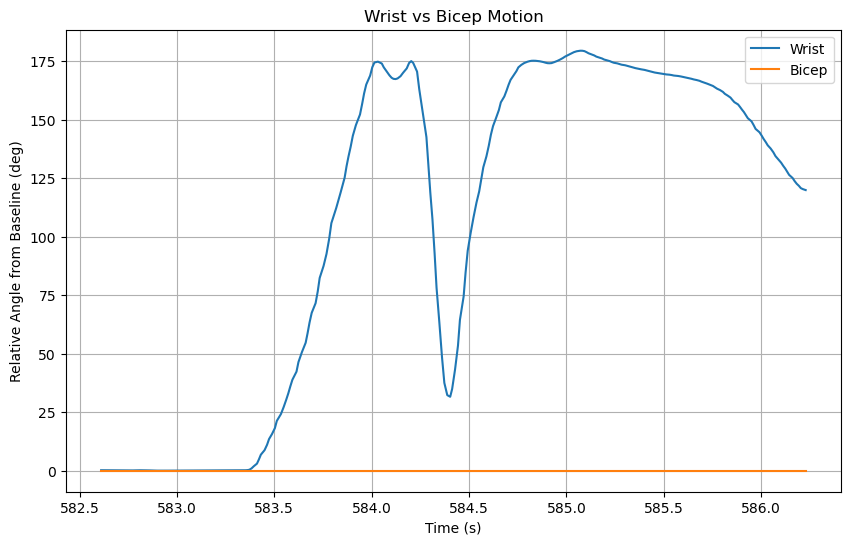

Correlation between wrist and bicep angles: nan


/root/miniconda3/envs/phenv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/root/miniconda3/envs/phenv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


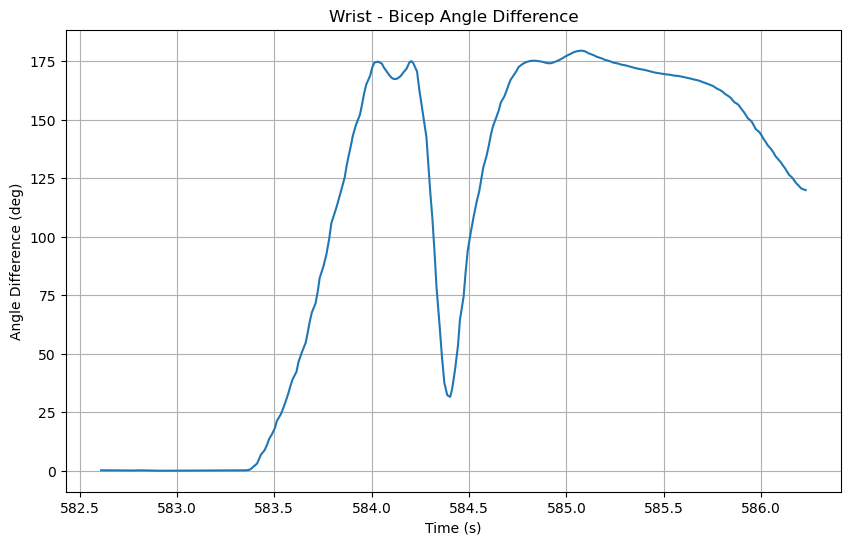

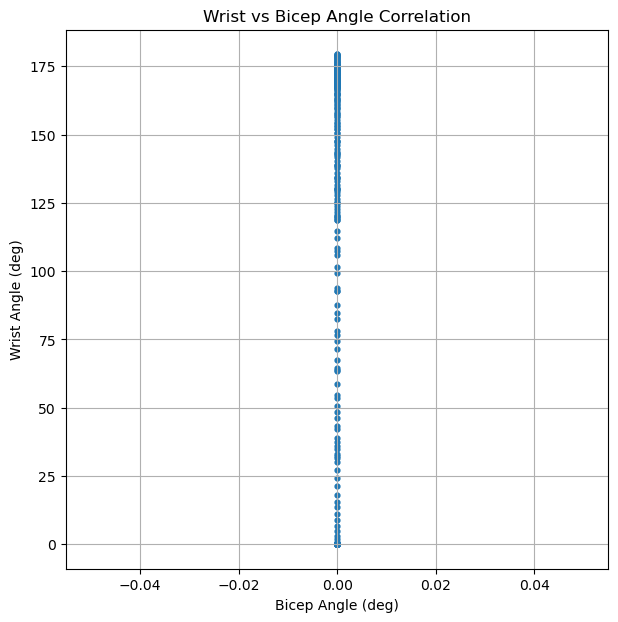

Wrist angle range: 0.03 to 179.42 deg
Bicep angle range: 0.00 to 0.00 deg
Mean angle difference: 105.12 deg
Std. dev. of angle difference: 72.12 deg


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1. Load CSV files
# ---------------------------
wrist = pd.read_csv("Wrist3rdSwing.csv")
bicep = pd.read_csv("Bicep3rdSwing.csv")

# ---------------------------
# 2. Convert timestamps to seconds
# ---------------------------
wrist["t"] = wrist["timestamp_ms"] / 1000.0
bicep["t"] = bicep["timestamp_ms"] / 1000.0

# Sort before merge_asof
wrist = wrist.sort_values("t").reset_index(drop=True)
bicep = bicep.sort_values("t").reset_index(drop=True)

# ---------------------------
# 3. Merge on nearest timestamp
# ---------------------------
df = pd.merge_asof(
    wrist,
    bicep,
    on="t",
    suffixes=("_w", "_b"),
    direction="nearest"
)

# ---------------------------
# 4. Quaternion helper functions
# ---------------------------
def quat_normalize(q):
    q = np.array(q, dtype=float)
    norm = np.linalg.norm(q)
    if norm == 0:
        return np.array([1.0, 0.0, 0.0, 0.0])
    return q / norm

def quat_conj(q):
    q = np.array(q, dtype=float)
    return np.array([q[0], -q[1], -q[2], -q[3]])

def quat_mult(q1, q2):
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])

def quat_relative_angle_deg(q0, q):
    q0 = quat_normalize(q0)
    q = quat_normalize(q)
    q_rel = quat_mult(quat_conj(q0), q)
    q_rel = quat_normalize(q_rel)
    angle_rad = 2 * np.arccos(np.clip(q_rel[0], -1.0, 1.0))
    angle_deg = np.degrees(angle_rad)

    # Keep angle in a cleaner 0–180 range
    if angle_deg > 180:
        angle_deg = 360 - angle_deg

    return angle_deg

# ---------------------------
# 5. Build baseline quaternions
#    using first 50 samples
# ---------------------------
baseline_n = 50

q0_w = df[["qw_w", "qx_w", "qy_w", "qz_w"]].iloc[:baseline_n].mean().values
q0_b = df[["qw_b", "qx_b", "qy_b", "qz_b"]].iloc[:baseline_n].mean().values

q0_w = quat_normalize(q0_w)
q0_b = quat_normalize(q0_b)

# ---------------------------
# 6. Compute relative angles
# ---------------------------
angles_w = []
angles_b = []

for _, row in df.iterrows():
    q_w = [row["qw_w"], row["qx_w"], row["qy_w"], row["qz_w"]]
    q_b = [row["qw_b"], row["qx_b"], row["qy_b"], row["qz_b"]]

    angles_w.append(quat_relative_angle_deg(q0_w, q_w))
    angles_b.append(quat_relative_angle_deg(q0_b, q_b))

df["angle_w_deg"] = angles_w
df["angle_b_deg"] = angles_b

# ---------------------------
# 7. Optional smoothing
# ---------------------------
window = 5
df["angle_w_smooth"] = df["angle_w_deg"].rolling(window=window, center=True, min_periods=1).mean()
df["angle_b_smooth"] = df["angle_b_deg"].rolling(window=window, center=True, min_periods=1).mean()

# ---------------------------
# 8. Plot wrist vs bicep motion
# ---------------------------
plt.figure(figsize=(10, 6))
plt.plot(df["t"], df["angle_w_smooth"], label="Wrist")
plt.plot(df["t"], df["angle_b_smooth"], label="Bicep")
plt.xlabel("Time (s)")
plt.ylabel("Relative Angle from Baseline (deg)")
plt.title("Wrist vs Bicep Motion")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------
# 9. Correlation
# ---------------------------
corr = df["angle_w_smooth"].corr(df["angle_b_smooth"])
print(f"Correlation between wrist and bicep angles: {corr:.4f}")

# ---------------------------
# 10. Difference over time
# ---------------------------
df["angle_diff"] = df["angle_w_smooth"] - df["angle_b_smooth"]

plt.figure(figsize=(10, 6))
plt.plot(df["t"], df["angle_diff"])
plt.xlabel("Time (s)")
plt.ylabel("Angle Difference (deg)")
plt.title("Wrist - Bicep Angle Difference")
plt.grid(True)
plt.show()

# ---------------------------
# 11. Scatter plot
# ---------------------------
plt.figure(figsize=(7, 7))
plt.scatter(df["angle_b_smooth"], df["angle_w_smooth"], s=12)
plt.xlabel("Bicep Angle (deg)")
plt.ylabel("Wrist Angle (deg)")
plt.title("Wrist vs Bicep Angle Correlation")
plt.grid(True)
plt.show()

# ---------------------------
# 12. Basic summary stats
# ---------------------------
print(f"Wrist angle range: {df['angle_w_smooth'].min():.2f} to {df['angle_w_smooth'].max():.2f} deg")
print(f"Bicep angle range: {df['angle_b_smooth'].min():.2f} to {df['angle_b_smooth'].max():.2f} deg")
print(f"Mean angle difference: {df['angle_diff'].mean():.2f} deg")
print(f"Std. dev. of angle difference: {df['angle_diff'].std():.2f} deg")

In [2]:
import pandas as pd
import numpy as np

wrist = pd.read_csv("Wrist3rdSwing.csv")
bicep = pd.read_csv("Bicep3rdSwing.csv")

print("WRIST COLUMNS:")
print(wrist.columns.tolist())
print()

print("BICEP COLUMNS:")
print(bicep.columns.tolist())
print()

print("WRIST SHAPE:", wrist.shape)
print("BICEP SHAPE:", bicep.shape)
print()

print("WRIST HEAD:")
print(wrist.head())
print()

print("BICEP HEAD:")
print(bicep.head())
print()

# Check whether quaternion values actually change
for name, df in [("WRIST", wrist), ("BICEP", bicep)]:
    print(f"--- {name} UNIQUE COUNTS ---")
    for col in ["timestamp_ms", "qw", "qx", "qy", "qz"]:
        if col in df.columns:
            print(col, "unique =", df[col].nunique())
    print()

WRIST COLUMNS:
['timestamp_ms', 'qw', 'qx', 'qy', 'qz', 'gx', 'gy', 'gz']

BICEP COLUMNS:
['timestamp_ms', 'qw', 'qx', 'qy', 'qz', 'gx', 'gy', 'gz']

WRIST SHAPE: (282, 8)
BICEP SHAPE: (553, 8)

WRIST HEAD:
   timestamp_ms        qw        qx        qy        qz        gx        gy  \
0        582611  0.624817  0.185303  0.730835 -0.202881  0.033203 -0.011719   
1        582621  0.624878  0.185242  0.730774 -0.202881 -0.023437 -0.013672   
2        582631  0.624939  0.185120  0.730774 -0.202820 -0.017578 -0.005859   
3        582641  0.624939  0.185059  0.730774 -0.202820  0.009766 -0.003906   
4        582652  0.624939  0.185120  0.730774 -0.202942  0.031250 -0.003906   

         gz  
0  0.007813  
1 -0.005859  
2 -0.005859  
3 -0.001953  
4 -0.003906  

BICEP HEAD:
   timestamp_ms        qw        qx        qy        qz        gx        gy  \
0        196823  0.456909  0.269653  0.727478 -0.435059 -0.035156 -0.019531   
1        196833  0.457031  0.269470  0.727600 -0.434875 -0.0742

Using wrist file: Wrist3rdSwing.csv
Using bicep file: Bicep3rdSwing.csv

WRIST COLUMNS:
['timestamp_ms', 'qw', 'qx', 'qy', 'qz', 'gx', 'gy', 'gz']

BICEP COLUMNS:
['timestamp_ms', 'qw', 'qx', 'qy', 'qz', 'gx', 'gy', 'gz']

WRIST SHAPE: (282, 8)
BICEP SHAPE: (553, 8)

WRIST HEAD:
   timestamp_ms        qw        qx        qy        qz        gx        gy  \
0        582611  0.624817  0.185303  0.730835 -0.202881  0.033203 -0.011719   
1        582621  0.624878  0.185242  0.730774 -0.202881 -0.023437 -0.013672   
2        582631  0.624939  0.185120  0.730774 -0.202820 -0.017578 -0.005859   
3        582641  0.624939  0.185059  0.730774 -0.202820  0.009766 -0.003906   
4        582652  0.624939  0.185120  0.730774 -0.202942  0.031250 -0.003906   

         gz  
0  0.007813  
1 -0.005859  
2 -0.005859  
3 -0.001953  
4 -0.003906  

BICEP HEAD:
   timestamp_ms        qw        qx        qy        qz        gx        gy  \
0        196823  0.456909  0.269653  0.727478 -0.435059 -0.035156 -0.

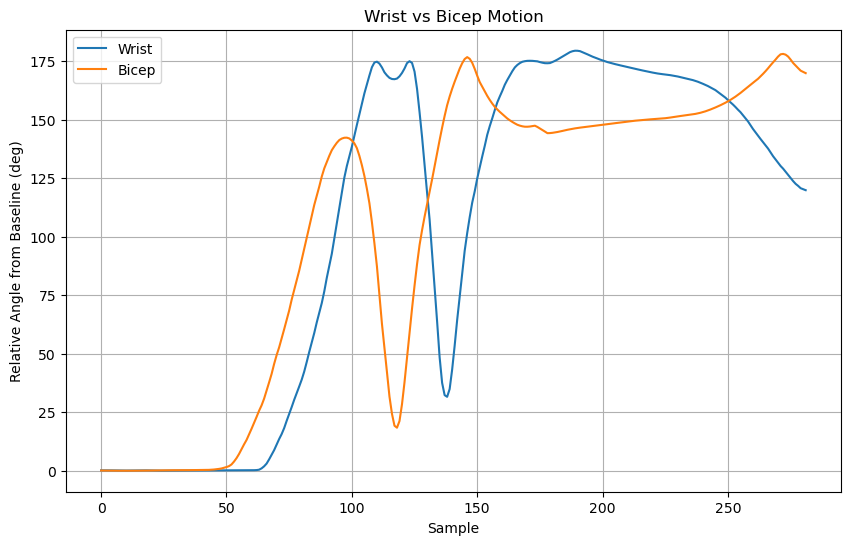

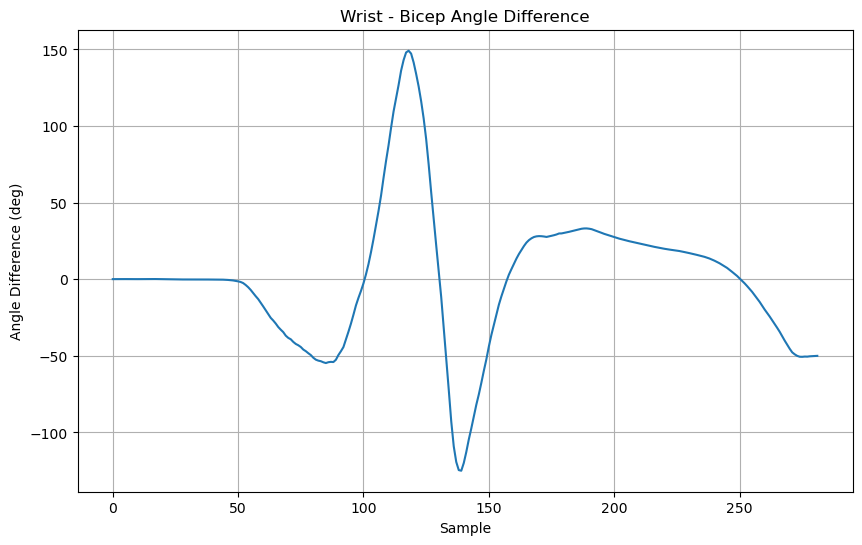

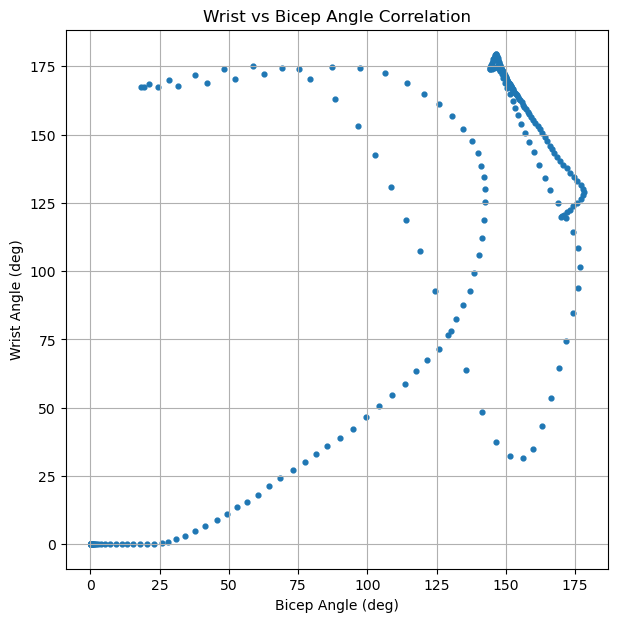

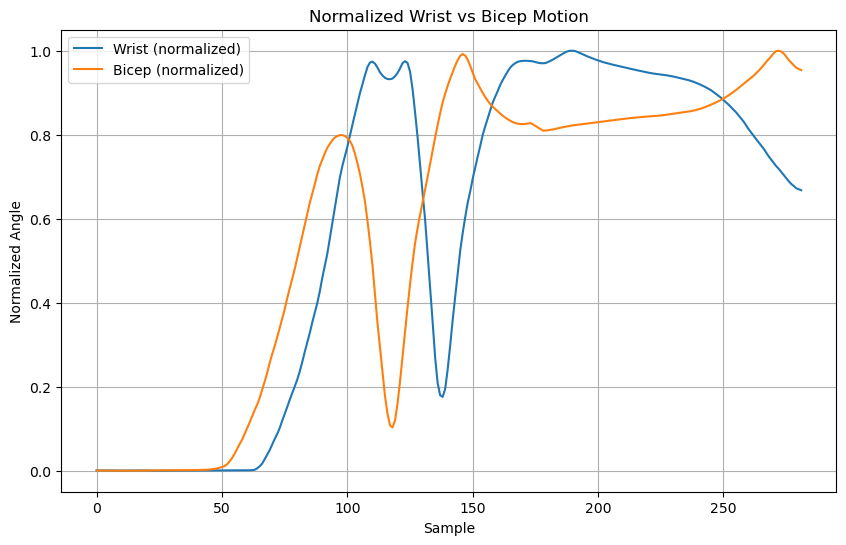

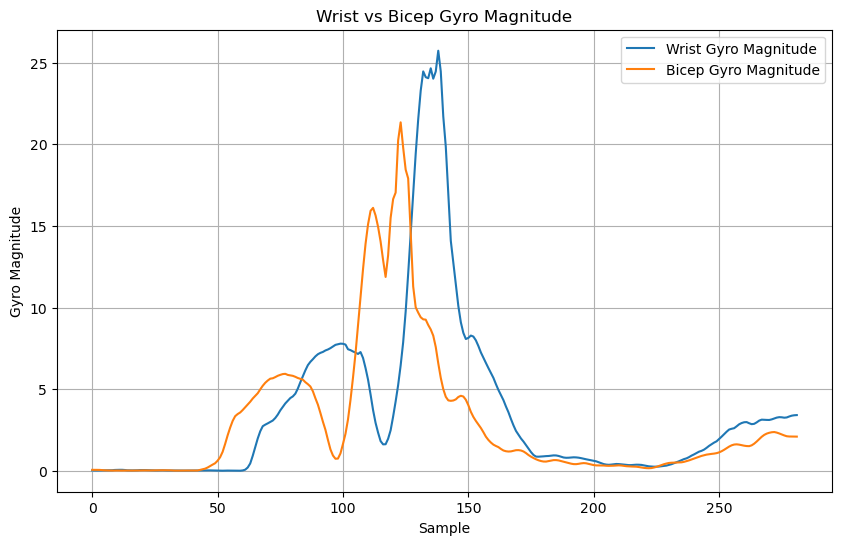

Saved results to wrist_bicep_comparison_results.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. LOAD THE CORRECT FILES
# =========================================================
wrist_file = "Wrist3rdSwing.csv"
bicep_file = "Bicep3rdSwing.csv"

wrist = pd.read_csv(wrist_file)
bicep = pd.read_csv(bicep_file)

print("Using wrist file:", wrist_file)
print("Using bicep file:", bicep_file)
print()

# =========================================================
# 2. BASIC FILE CHECKS
# =========================================================
print("WRIST COLUMNS:")
print(wrist.columns.tolist())
print()

print("BICEP COLUMNS:")
print(bicep.columns.tolist())
print()

print("WRIST SHAPE:", wrist.shape)
print("BICEP SHAPE:", bicep.shape)
print()

print("WRIST HEAD:")
print(wrist.head())
print()

print("BICEP HEAD:")
print(bicep.head())
print()

# =========================================================
# 3. CHECK THAT QUATERNIONS ARE ACTUALLY CHANGING
# =========================================================
print("--- WRIST UNIQUE COUNTS ---")
for col in ["timestamp_ms", "qw", "qx", "qy", "qz"]:
    print(col, "unique =", wrist[col].nunique())
print()

print("--- BICEP UNIQUE COUNTS ---")
for col in ["timestamp_ms", "qw", "qx", "qy", "qz"]:
    print(col, "unique =", bicep[col].nunique())
print()

# =========================================================
# 4. KEEP ONLY NEEDED COLUMNS
# =========================================================
needed = ["timestamp_ms", "qw", "qx", "qy", "qz", "gx", "gy", "gz"]
wrist = wrist[needed].copy()
bicep = bicep[needed].copy()

# =========================================================
# 5. MATCH BY SAMPLE INDEX, NOT TIMESTAMP
#    (because the two sensors may have different time origins)
# =========================================================
n = min(len(wrist), len(bicep))
wrist = wrist.iloc[:n].reset_index(drop=True)
bicep = bicep.iloc[:n].reset_index(drop=True)

df = pd.DataFrame({
    "sample": np.arange(n),
    "timestamp_w": wrist["timestamp_ms"],
    "timestamp_b": bicep["timestamp_ms"],

    "qw_w": wrist["qw"],
    "qx_w": wrist["qx"],
    "qy_w": wrist["qy"],
    "qz_w": wrist["qz"],

    "qw_b": bicep["qw"],
    "qx_b": bicep["qx"],
    "qy_b": bicep["qy"],
    "qz_b": bicep["qz"],

    "gx_w": wrist["gx"],
    "gy_w": wrist["gy"],
    "gz_w": wrist["gz"],

    "gx_b": bicep["gx"],
    "gy_b": bicep["gy"],
    "gz_b": bicep["gz"],
})

print("Number of matched samples:", n)
print()

# =========================================================
# 6. QUATERNION HELPER FUNCTIONS
# =========================================================
def quat_normalize(q):
    q = np.array(q, dtype=float)
    norm = np.linalg.norm(q)
    if norm == 0:
        return np.array([1.0, 0.0, 0.0, 0.0])
    return q / norm

def quat_conj(q):
    return np.array([q[0], -q[1], -q[2], -q[3]])

def quat_mult(q1, q2):
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])

def relative_angle_deg(q0, q):
    q0 = quat_normalize(q0)
    q = quat_normalize(q)

    q_rel = quat_mult(quat_conj(q0), q)
    q_rel = quat_normalize(q_rel)

    angle = 2 * np.arccos(np.clip(q_rel[0], -1.0, 1.0))
    angle = np.degrees(angle)

    if angle > 180:
        angle = 360 - angle

    return angle

# =========================================================
# 7. BASELINE QUATERNIONS
#    Use first few samples as starting orientation
# =========================================================
baseline_n = min(20, n)

q0_w = quat_normalize(
    df[["qw_w", "qx_w", "qy_w", "qz_w"]].iloc[:baseline_n].mean().values
)

q0_b = quat_normalize(
    df[["qw_b", "qx_b", "qy_b", "qz_b"]].iloc[:baseline_n].mean().values
)

print("Wrist baseline quaternion:", q0_w)
print("Bicep baseline quaternion:", q0_b)
print()

# =========================================================
# 8. COMPUTE RELATIVE ANGLE FOR BOTH SENSORS
# =========================================================
angles_w = []
angles_b = []

for _, row in df.iterrows():
    q_w = [row["qw_w"], row["qx_w"], row["qy_w"], row["qz_w"]]
    q_b = [row["qw_b"], row["qx_b"], row["qy_b"], row["qz_b"]]

    angles_w.append(relative_angle_deg(q0_w, q_w))
    angles_b.append(relative_angle_deg(q0_b, q_b))

df["angle_w"] = angles_w
df["angle_b"] = angles_b

# =========================================================
# 9. OPTIONAL SMOOTHING
# =========================================================
window = 5
df["angle_w_s"] = df["angle_w"].rolling(window=window, center=True, min_periods=1).mean()
df["angle_b_s"] = df["angle_b"].rolling(window=window, center=True, min_periods=1).mean()

# =========================================================
# 10. PRINT ANGLE RANGES
# =========================================================
print("Wrist angle range: {:.2f} to {:.2f} deg".format(df["angle_w_s"].min(), df["angle_w_s"].max()))
print("Bicep angle range: {:.2f} to {:.2f} deg".format(df["angle_b_s"].min(), df["angle_b_s"].max()))
print()

# =========================================================
# 11. CORRELATION
# =========================================================
if df["angle_w_s"].std() > 0 and df["angle_b_s"].std() > 0:
    corr = df["angle_w_s"].corr(df["angle_b_s"])
    print("Correlation between wrist and bicep angles: {:.4f}".format(corr))
else:
    corr = np.nan
    print("Correlation cannot be computed because one signal is constant.")
print()

# =========================================================
# 12. DIFFERENCE SIGNAL
# =========================================================
df["angle_diff"] = df["angle_w_s"] - df["angle_b_s"]

print("Mean angle difference: {:.2f} deg".format(df["angle_diff"].mean()))
print("Std. dev. of angle difference: {:.2f} deg".format(df["angle_diff"].std()))
print()

# =========================================================
# 13. PLOT 1: WRIST VS BICEP MOTION
# =========================================================
plt.figure(figsize=(10, 6))
plt.plot(df["sample"], df["angle_w_s"], label="Wrist")
plt.plot(df["sample"], df["angle_b_s"], label="Bicep")
plt.xlabel("Sample")
plt.ylabel("Relative Angle from Baseline (deg)")
plt.title("Wrist vs Bicep Motion")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 14. PLOT 2: DIFFERENCE OVER TIME
# =========================================================
plt.figure(figsize=(10, 6))
plt.plot(df["sample"], df["angle_diff"])
plt.xlabel("Sample")
plt.ylabel("Angle Difference (deg)")
plt.title("Wrist - Bicep Angle Difference")
plt.grid(True)
plt.show()

# =========================================================
# 15. PLOT 3: SCATTER CORRELATION
# =========================================================
plt.figure(figsize=(7, 7))
plt.scatter(df["angle_b_s"], df["angle_w_s"], s=12)
plt.xlabel("Bicep Angle (deg)")
plt.ylabel("Wrist Angle (deg)")
plt.title("Wrist vs Bicep Angle Correlation")
plt.grid(True)
plt.show()

# =========================================================
# 16. OPTIONAL: NORMALIZED SHAPE COMPARISON
# =========================================================
def normalize_signal(x):
    x = np.array(x, dtype=float)
    if x.max() - x.min() == 0:
        return np.zeros_like(x)
    return (x - x.min()) / (x.max() - x.min())

df["angle_w_norm"] = normalize_signal(df["angle_w_s"])
df["angle_b_norm"] = normalize_signal(df["angle_b_s"])

plt.figure(figsize=(10, 6))
plt.plot(df["sample"], df["angle_w_norm"], label="Wrist (normalized)")
plt.plot(df["sample"], df["angle_b_norm"], label="Bicep (normalized)")
plt.xlabel("Sample")
plt.ylabel("Normalized Angle")
plt.title("Normalized Wrist vs Bicep Motion")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 17. OPTIONAL: GYRO MAGNITUDE COMPARISON
# =========================================================
df["gyro_w"] = np.sqrt(df["gx_w"]**2 + df["gy_w"]**2 + df["gz_w"]**2)
df["gyro_b"] = np.sqrt(df["gx_b"]**2 + df["gy_b"]**2 + df["gz_b"]**2)

df["gyro_w_s"] = df["gyro_w"].rolling(window=window, center=True, min_periods=1).mean()
df["gyro_b_s"] = df["gyro_b"].rolling(window=window, center=True, min_periods=1).mean()

plt.figure(figsize=(10, 6))
plt.plot(df["sample"], df["gyro_w_s"], label="Wrist Gyro Magnitude")
plt.plot(df["sample"], df["gyro_b_s"], label="Bicep Gyro Magnitude")
plt.xlabel("Sample")
plt.ylabel("Gyro Magnitude")
plt.title("Wrist vs Bicep Gyro Magnitude")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 18. SAVE RESULTS IF YOU WANT
# =========================================================
df.to_csv("wrist_bicep_comparison_results.csv", index=False)
print("Saved results to wrist_bicep_comparison_results.csv")

Using wrist file: Wrist3rdSwing.csv
Using bicep file: Bicep3rdSwing.csv

WRIST SHAPE: (282, 8)
BICEP SHAPE: (553, 8)

--- WRIST UNIQUE COUNTS ---
timestamp_ms unique = 282
qw unique = 231
qx unique = 250
qy unique = 236
qz unique = 235

--- BICEP UNIQUE COUNTS ---
timestamp_ms unique = 553
qw unique = 503
qx unique = 474
qy unique = 514
qz unique = 508

Normalized gyro correlation before alignment: 0.4997
Best shift: 17 samples
Normalized gyro correlation after alignment: 0.9478

Trimming first 17 samples from wrist
Number of aligned samples: 265

Wrist baseline quaternion: [ 0.62457828  0.18662376  0.7303184  -0.20422678]
Bicep baseline quaternion: [ 0.45730847  0.26866775  0.72790167 -0.43456388]

Wrist angle range: 0.02 to 179.42 deg
Bicep angle range: 0.02 to 176.69 deg
Correlation between wrist and bicep angles: 0.9513
Mean angle difference: 11.74 deg
Std. dev. of angle difference: 21.35 deg



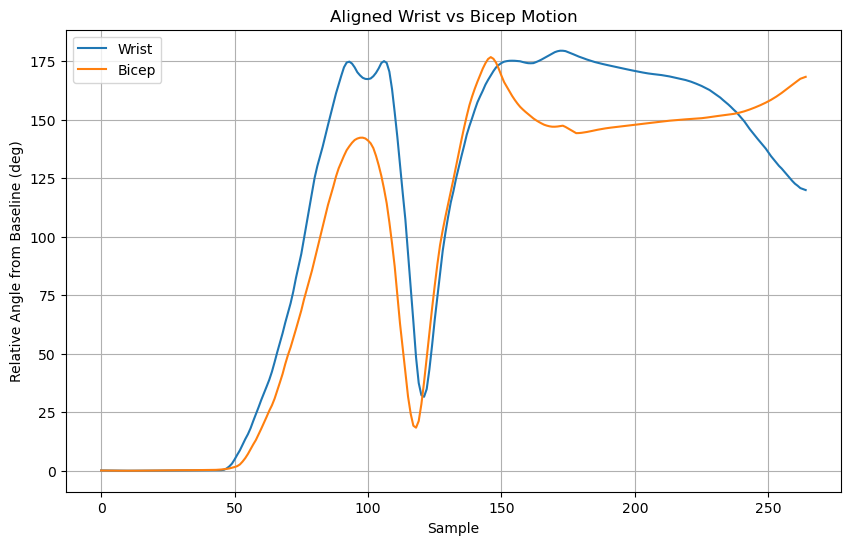

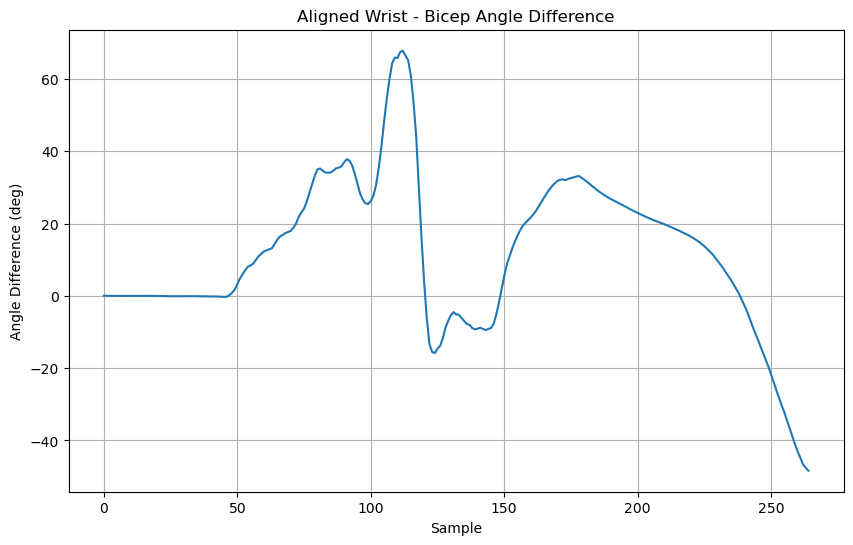

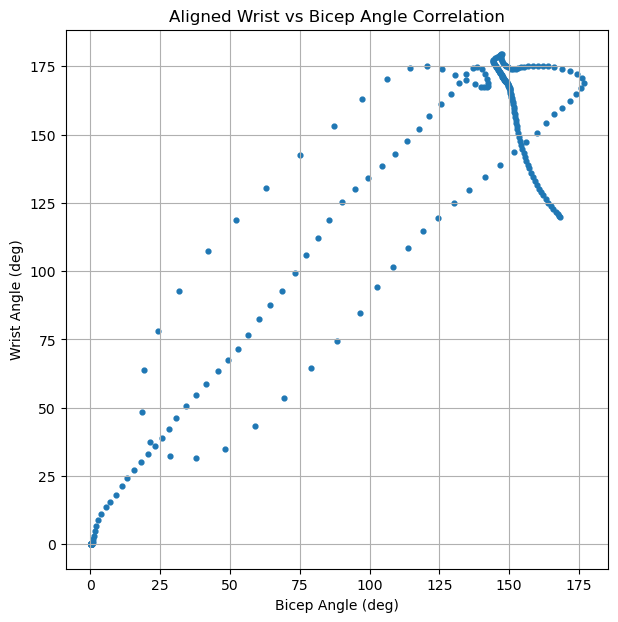

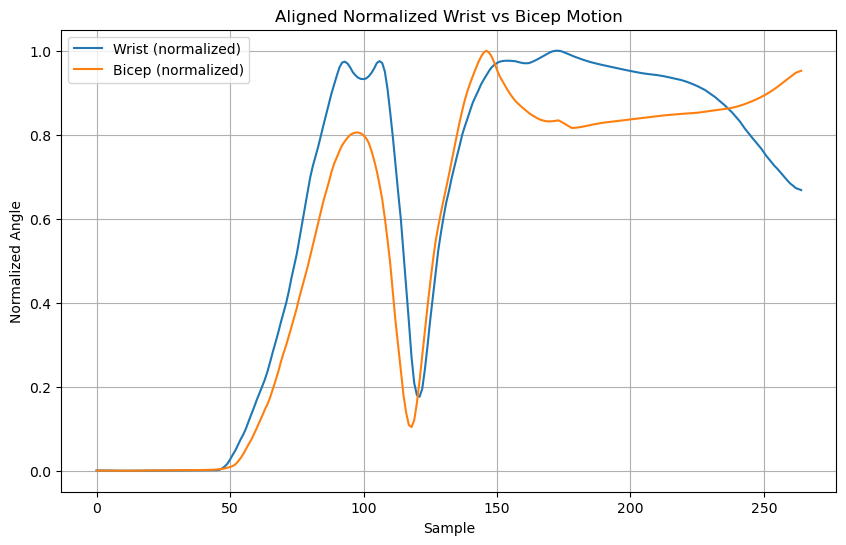

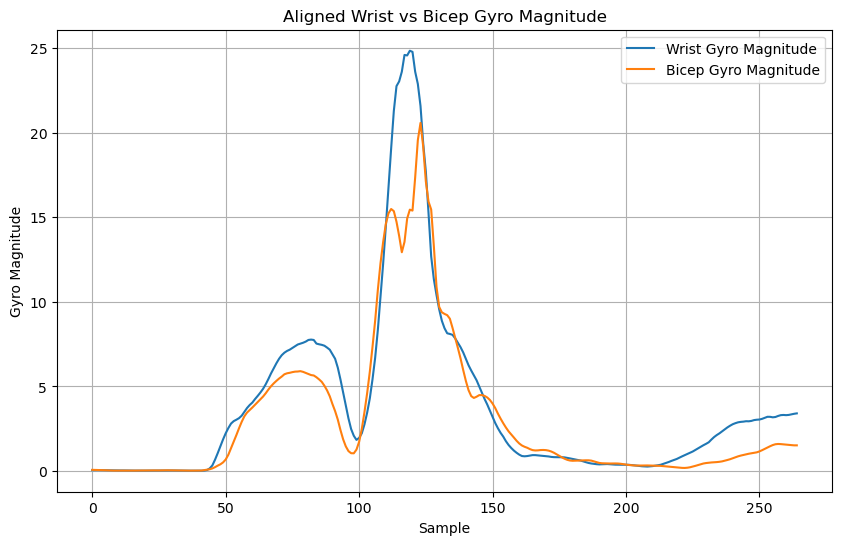

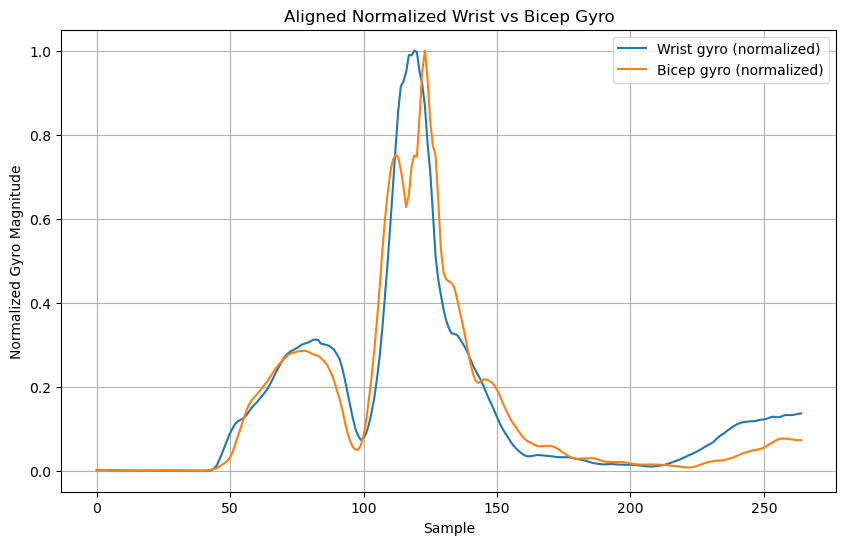

Saved results to aligned_wrist_bicep_comparison_results.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. LOAD FILES
# =========================================================
wrist_file = "Wrist3rdSwing.csv"
bicep_file = "Bicep3rdSwing.csv"

wrist = pd.read_csv(wrist_file)
bicep = pd.read_csv(bicep_file)

print("Using wrist file:", wrist_file)
print("Using bicep file:", bicep_file)
print()

# =========================================================
# 2. BASIC CHECKS
# =========================================================
print("WRIST SHAPE:", wrist.shape)
print("BICEP SHAPE:", bicep.shape)
print()

print("--- WRIST UNIQUE COUNTS ---")
for col in ["timestamp_ms", "qw", "qx", "qy", "qz"]:
    print(col, "unique =", wrist[col].nunique())
print()

print("--- BICEP UNIQUE COUNTS ---")
for col in ["timestamp_ms", "qw", "qx", "qy", "qz"]:
    print(col, "unique =", bicep[col].nunique())
print()

# Keep only needed columns
needed = ["timestamp_ms", "qw", "qx", "qy", "qz", "gx", "gy", "gz"]
wrist = wrist[needed].copy()
bicep = bicep[needed].copy()

# =========================================================
# 3. GYRO MAGNITUDE FOR ALIGNMENT
# =========================================================
wrist["gyro_mag"] = np.sqrt(wrist["gx"]**2 + wrist["gy"]**2 + wrist["gz"]**2)
bicep["gyro_mag"] = np.sqrt(bicep["gx"]**2 + bicep["gy"]**2 + bicep["gz"]**2)

# Smooth slightly
window = 7
wrist["gyro_s"] = wrist["gyro_mag"].rolling(window=window, center=True, min_periods=1).mean()
bicep["gyro_s"] = bicep["gyro_mag"].rolling(window=window, center=True, min_periods=1).mean()

def normalize_signal(x):
    x = np.array(x, dtype=float)
    if x.max() - x.min() == 0:
        return np.zeros_like(x)
    return (x - x.min()) / (x.max() - x.min())

w_raw = normalize_signal(wrist["gyro_s"].values)
b_raw = normalize_signal(bicep["gyro_s"].values)

n0 = min(len(w_raw), len(b_raw))
w_raw = w_raw[:n0]
b_raw = b_raw[:n0]

# Correlation before alignment
if np.std(w_raw) > 0 and np.std(b_raw) > 0:
    corr_before = np.corrcoef(w_raw, b_raw)[0, 1]
else:
    corr_before = np.nan

print(f"Normalized gyro correlation before alignment: {corr_before:.4f}")

# =========================================================
# 4. FIND BEST SAMPLE SHIFT AUTOMATICALLY
# =========================================================
max_shift = 40   # search from -40 to +40 samples
best_shift = 0
best_corr = -1

for shift in range(-max_shift, max_shift + 1):
    if shift > 0:
        # trim wrist start
        w_seg = w_raw[shift:]
        b_seg = b_raw[:len(w_seg)]
    elif shift < 0:
        # trim bicep start
        b_seg = b_raw[-shift:]
        w_seg = w_raw[:len(b_seg)]
    else:
        w_seg = w_raw
        b_seg = b_raw

    if len(w_seg) > 10 and np.std(w_seg) > 0 and np.std(b_seg) > 0:
        corr = np.corrcoef(w_seg, b_seg)[0, 1]
        if corr > best_corr:
            best_corr = corr
            best_shift = shift

print(f"Best shift: {best_shift} samples")
print(f"Normalized gyro correlation after alignment: {best_corr:.4f}")
print()

# =========================================================
# 5. APPLY SHIFT
# =========================================================
if best_shift > 0:
    print(f"Trimming first {best_shift} samples from wrist")
    wrist = wrist.iloc[best_shift:].reset_index(drop=True)
elif best_shift < 0:
    print(f"Trimming first {-best_shift} samples from bicep")
    bicep = bicep.iloc[-best_shift:].reset_index(drop=True)
else:
    print("No shift applied")

# Trim to same length after shift
n = min(len(wrist), len(bicep))
wrist = wrist.iloc[:n].reset_index(drop=True)
bicep = bicep.iloc[:n].reset_index(drop=True)

print("Number of aligned samples:", n)
print()

# =========================================================
# 6. BUILD COMBINED DATAFRAME
# =========================================================
df = pd.DataFrame({
    "sample": np.arange(n),
    "timestamp_w": wrist["timestamp_ms"],
    "timestamp_b": bicep["timestamp_ms"],

    "qw_w": wrist["qw"],
    "qx_w": wrist["qx"],
    "qy_w": wrist["qy"],
    "qz_w": wrist["qz"],

    "qw_b": bicep["qw"],
    "qx_b": bicep["qx"],
    "qy_b": bicep["qy"],
    "qz_b": bicep["qz"],

    "gx_w": wrist["gx"],
    "gy_w": wrist["gy"],
    "gz_w": wrist["gz"],

    "gx_b": bicep["gx"],
    "gy_b": bicep["gy"],
    "gz_b": bicep["gz"],
})

# =========================================================
# 7. QUATERNION FUNCTIONS
# =========================================================
def quat_normalize(q):
    q = np.array(q, dtype=float)
    norm = np.linalg.norm(q)
    if norm == 0:
        return np.array([1.0, 0.0, 0.0, 0.0])
    return q / norm

def quat_conj(q):
    return np.array([q[0], -q[1], -q[2], -q[3]])

def quat_mult(q1, q2):
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])

def relative_angle_deg(q0, q):
    q0 = quat_normalize(q0)
    q = quat_normalize(q)
    q_rel = quat_mult(quat_conj(q0), q)
    q_rel = quat_normalize(q_rel)
    angle = 2 * np.arccos(np.clip(q_rel[0], -1.0, 1.0))
    angle = np.degrees(angle)
    if angle > 180:
        angle = 360 - angle
    return angle

# =========================================================
# 8. BASELINE ORIENTATION
# =========================================================
baseline_n = min(20, n)

q0_w = quat_normalize(
    df[["qw_w", "qx_w", "qy_w", "qz_w"]].iloc[:baseline_n].mean().values
)

q0_b = quat_normalize(
    df[["qw_b", "qx_b", "qy_b", "qz_b"]].iloc[:baseline_n].mean().values
)

print("Wrist baseline quaternion:", q0_w)
print("Bicep baseline quaternion:", q0_b)
print()

# =========================================================
# 9. COMPUTE RELATIVE ANGLES
# =========================================================
angles_w = []
angles_b = []

for _, row in df.iterrows():
    q_w = [row["qw_w"], row["qx_w"], row["qy_w"], row["qz_w"]]
    q_b = [row["qw_b"], row["qx_b"], row["qy_b"], row["qz_b"]]

    angles_w.append(relative_angle_deg(q0_w, q_w))
    angles_b.append(relative_angle_deg(q0_b, q_b))

df["angle_w"] = angles_w
df["angle_b"] = angles_b

# Smooth angle signals
angle_window = 5
df["angle_w_s"] = df["angle_w"].rolling(window=angle_window, center=True, min_periods=1).mean()
df["angle_b_s"] = df["angle_b"].rolling(window=angle_window, center=True, min_periods=1).mean()

# =========================================================
# 10. CORRELATION + SUMMARY
# =========================================================
if df["angle_w_s"].std() > 0 and df["angle_b_s"].std() > 0:
    angle_corr = df["angle_w_s"].corr(df["angle_b_s"])
else:
    angle_corr = np.nan

df["angle_diff"] = df["angle_w_s"] - df["angle_b_s"]

print("Wrist angle range: {:.2f} to {:.2f} deg".format(df["angle_w_s"].min(), df["angle_w_s"].max()))
print("Bicep angle range: {:.2f} to {:.2f} deg".format(df["angle_b_s"].min(), df["angle_b_s"].max()))
print("Correlation between wrist and bicep angles: {:.4f}".format(angle_corr))
print("Mean angle difference: {:.2f} deg".format(df["angle_diff"].mean()))
print("Std. dev. of angle difference: {:.2f} deg".format(df["angle_diff"].std()))
print()

# =========================================================
# 11. RECOMPUTE ALIGNED GYRO FOR PLOTTING
# =========================================================
df["gyro_w"] = np.sqrt(df["gx_w"]**2 + df["gy_w"]**2 + df["gz_w"]**2)
df["gyro_b"] = np.sqrt(df["gx_b"]**2 + df["gy_b"]**2 + df["gz_b"]**2)

df["gyro_w_s"] = df["gyro_w"].rolling(window=window, center=True, min_periods=1).mean()
df["gyro_b_s"] = df["gyro_b"].rolling(window=window, center=True, min_periods=1).mean()

df["gyro_w_norm"] = normalize_signal(df["gyro_w_s"])
df["gyro_b_norm"] = normalize_signal(df["gyro_b_s"])

# Normalized angles too
df["angle_w_norm"] = normalize_signal(df["angle_w_s"])
df["angle_b_norm"] = normalize_signal(df["angle_b_s"])

# =========================================================
# 12. PLOT 1: ALIGNED ANGLE COMPARISON
# =========================================================
plt.figure(figsize=(10, 6))
plt.plot(df["sample"], df["angle_w_s"], label="Wrist")
plt.plot(df["sample"], df["angle_b_s"], label="Bicep")
plt.xlabel("Sample")
plt.ylabel("Relative Angle from Baseline (deg)")
plt.title("Aligned Wrist vs Bicep Motion")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 13. PLOT 2: ANGLE DIFFERENCE
# =========================================================
plt.figure(figsize=(10, 6))
plt.plot(df["sample"], df["angle_diff"])
plt.xlabel("Sample")
plt.ylabel("Angle Difference (deg)")
plt.title("Aligned Wrist - Bicep Angle Difference")
plt.grid(True)
plt.show()

# =========================================================
# 14. PLOT 3: ANGLE SCATTER
# =========================================================
plt.figure(figsize=(7, 7))
plt.scatter(df["angle_b_s"], df["angle_w_s"], s=12)
plt.xlabel("Bicep Angle (deg)")
plt.ylabel("Wrist Angle (deg)")
plt.title("Aligned Wrist vs Bicep Angle Correlation")
plt.grid(True)
plt.show()

# =========================================================
# 15. PLOT 4: NORMALIZED ANGLE SHAPE COMPARISON
# =========================================================
plt.figure(figsize=(10, 6))
plt.plot(df["sample"], df["angle_w_norm"], label="Wrist (normalized)")
plt.plot(df["sample"], df["angle_b_norm"], label="Bicep (normalized)")
plt.xlabel("Sample")
plt.ylabel("Normalized Angle")
plt.title("Aligned Normalized Wrist vs Bicep Motion")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 16. PLOT 5: ALIGNED GYRO MAGNITUDE
# =========================================================
plt.figure(figsize=(10, 6))
plt.plot(df["sample"], df["gyro_w_s"], label="Wrist Gyro Magnitude")
plt.plot(df["sample"], df["gyro_b_s"], label="Bicep Gyro Magnitude")
plt.xlabel("Sample")
plt.ylabel("Gyro Magnitude")
plt.title("Aligned Wrist vs Bicep Gyro Magnitude")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 17. OPTIONAL: ALIGNED NORMALIZED GYRO
# =========================================================
plt.figure(figsize=(10, 6))
plt.plot(df["sample"], df["gyro_w_norm"], label="Wrist gyro (normalized)")
plt.plot(df["sample"], df["gyro_b_norm"], label="Bicep gyro (normalized)")
plt.xlabel("Sample")
plt.ylabel("Normalized Gyro Magnitude")
plt.title("Aligned Normalized Wrist vs Bicep Gyro")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 18. SAVE RESULTS
# =========================================================
df.to_csv("aligned_wrist_bicep_comparison_results.csv", index=False)
print("Saved results to aligned_wrist_bicep_comparison_results.csv")

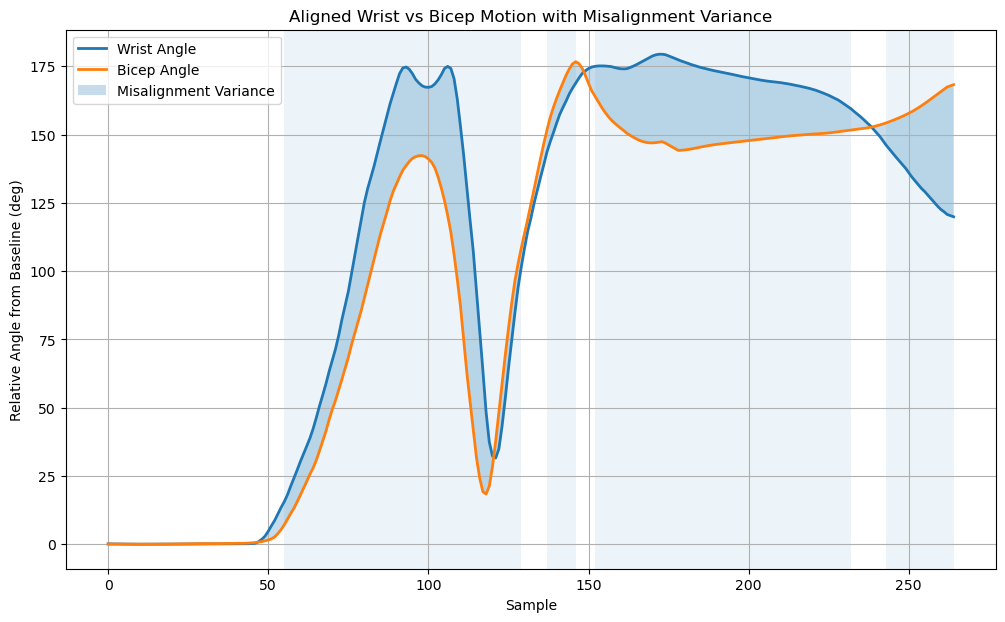

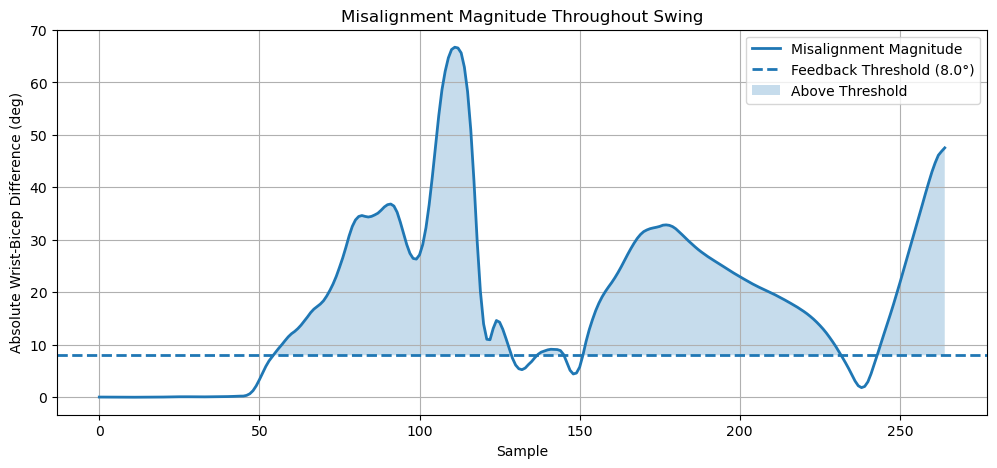

Peak misalignment: 66.70 deg at sample 111


In [5]:
# =========================================================
# 12. MISALIGNMENT METRICS
# =========================================================
# Signed difference already exists:
df["angle_diff"] = df["angle_w_s"] - df["angle_b_s"]

# Absolute difference = true size of misalignment
df["misalignment_deg"] = np.abs(df["angle_diff"])

# Smooth the misalignment slightly so the graph is cleaner
misalign_window = 5
df["misalignment_s"] = (
    df["misalignment_deg"]
    .rolling(window=misalign_window, center=True, min_periods=1)
    .mean()
)

# Optional threshold for when feedback would trigger
misalignment_threshold = 8.0  # degrees, adjust as needed

# Flag where misalignment exceeds threshold
df["misaligned_flag"] = df["misalignment_s"] > misalignment_threshold

# =========================================================
# 13. PLOT 1: WRIST VS BICEP WITH MISALIGNMENT AREA
# =========================================================
plt.figure(figsize=(12, 7))

# Main wrist and bicep lines
plt.plot(df["sample"], df["angle_w_s"], label="Wrist Angle", linewidth=2)
plt.plot(df["sample"], df["angle_b_s"], label="Bicep Angle", linewidth=2)

# Fill area between curves to show variance directly
plt.fill_between(
    df["sample"],
    df["angle_w_s"],
    df["angle_b_s"],
    alpha=0.25,
    label="Misalignment Variance"
)

# Highlight threshold exceedance regions
for i in range(len(df) - 1):
    if df.loc[i, "misaligned_flag"]:
        plt.axvspan(df.loc[i, "sample"], df.loc[i + 1, "sample"], alpha=0.08)

plt.xlabel("Sample")
plt.ylabel("Relative Angle from Baseline (deg)")
plt.title("Aligned Wrist vs Bicep Motion with Misalignment Variance")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 14. PLOT 2: MISALIGNMENT MAGNITUDE ITSELF
# =========================================================
plt.figure(figsize=(12, 5))

plt.plot(
    df["sample"],
    df["misalignment_s"],
    label="Misalignment Magnitude",
    linewidth=2
)

plt.axhline(
    misalignment_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Feedback Threshold ({misalignment_threshold:.1f}°)"
)

# Shade only where threshold is exceeded
plt.fill_between(
    df["sample"],
    df["misalignment_s"],
    misalignment_threshold,
    where=df["misalignment_s"] > misalignment_threshold,
    alpha=0.25,
    interpolate=True,
    label="Above Threshold"
)

plt.xlabel("Sample")
plt.ylabel("Absolute Wrist-Bicep Difference (deg)")
plt.title("Misalignment Magnitude Throughout Swing")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 15. OPTIONAL: LABEL WORST MISALIGNMENT POINT
# =========================================================
peak_idx = df["misalignment_s"].idxmax()
peak_sample = df.loc[peak_idx, "sample"]
peak_value = df.loc[peak_idx, "misalignment_s"]

print(f"Peak misalignment: {peak_value:.2f} deg at sample {peak_sample}")

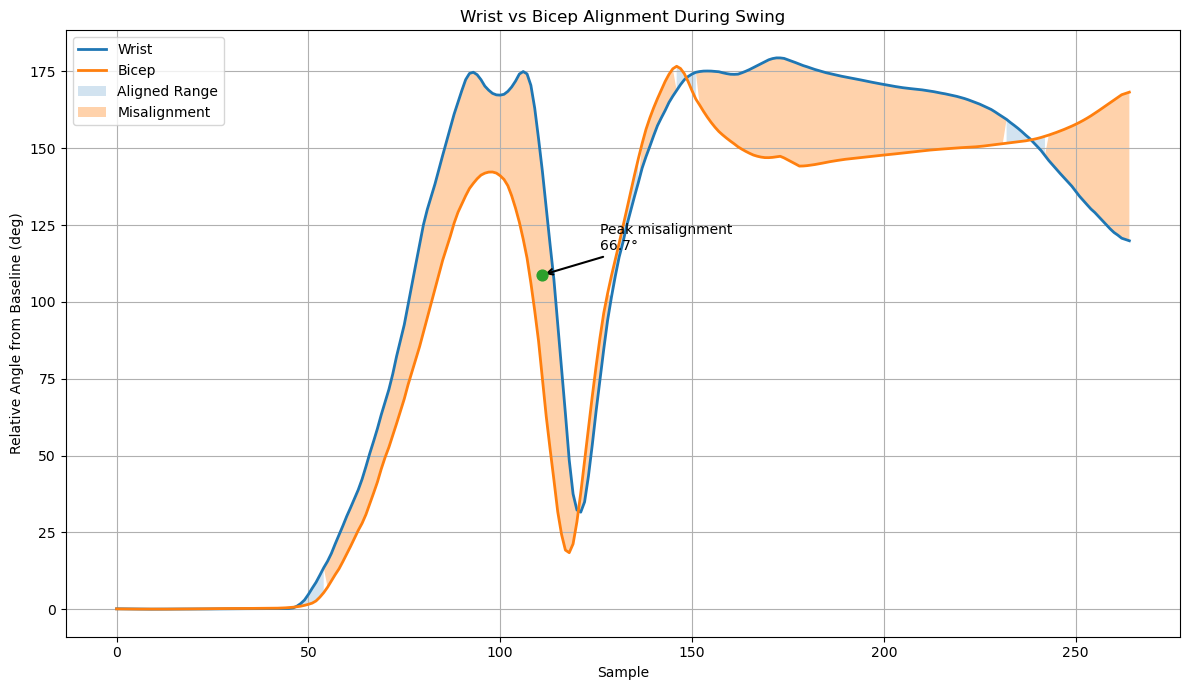

In [6]:
# =========================================================
# 12. MISALIGNMENT METRICS
# =========================================================
df["angle_diff"] = df["angle_w_s"] - df["angle_b_s"]
df["misalignment_deg"] = np.abs(df["angle_diff"])

# Smooth the misalignment a little so it looks cleaner
misalign_window = 5
df["misalignment_s"] = (
    df["misalignment_deg"]
    .rolling(window=misalign_window, center=True, min_periods=1)
    .mean()
)

# Threshold for "noticeable" misalignment / possible haptic trigger
misalignment_threshold = 8.0  # degrees, change if needed

# =========================================================
# 13. SINGLE POLISHED GRAPH
# =========================================================
plt.figure(figsize=(12, 7))

# Main motion lines
plt.plot(
    df["sample"],
    df["angle_w_s"],
    label="Wrist",
    linewidth=2
)

plt.plot(
    df["sample"],
    df["angle_b_s"],
    label="Bicep",
    linewidth=2
)

# Green shading where alignment is good
plt.fill_between(
    df["sample"],
    df["angle_w_s"],
    df["angle_b_s"],
    where=(df["misalignment_s"] <= misalignment_threshold),
    interpolate=True,
    alpha=0.20,
    label="Aligned Range"
)

# Red/yellow shading where misalignment is larger
plt.fill_between(
    df["sample"],
    df["angle_w_s"],
    df["angle_b_s"],
    where=(df["misalignment_s"] > misalignment_threshold),
    interpolate=True,
    alpha=0.35,
    label="Misalignment"
)

# Optional: mark the peak misalignment point
peak_idx = df["misalignment_s"].idxmax()
peak_sample = df.loc[peak_idx, "sample"]
peak_wrist = df.loc[peak_idx, "angle_w_s"]
peak_bicep = df.loc[peak_idx, "angle_b_s"]
peak_value = df.loc[peak_idx, "misalignment_s"]

mid_y = 0.5 * (peak_wrist + peak_bicep)

plt.scatter([peak_sample], [mid_y], s=60, zorder=5)
plt.annotate(
    f"Peak misalignment\n{peak_value:.1f}°",
    xy=(peak_sample, mid_y),
    xytext=(peak_sample + 15, mid_y + 8),
    arrowprops=dict(arrowstyle="->", lw=1.5),
    fontsize=10
)

plt.xlabel("Sample")
plt.ylabel("Relative Angle from Baseline (deg)")
plt.title("Wrist vs Bicep Alignment During Swing")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

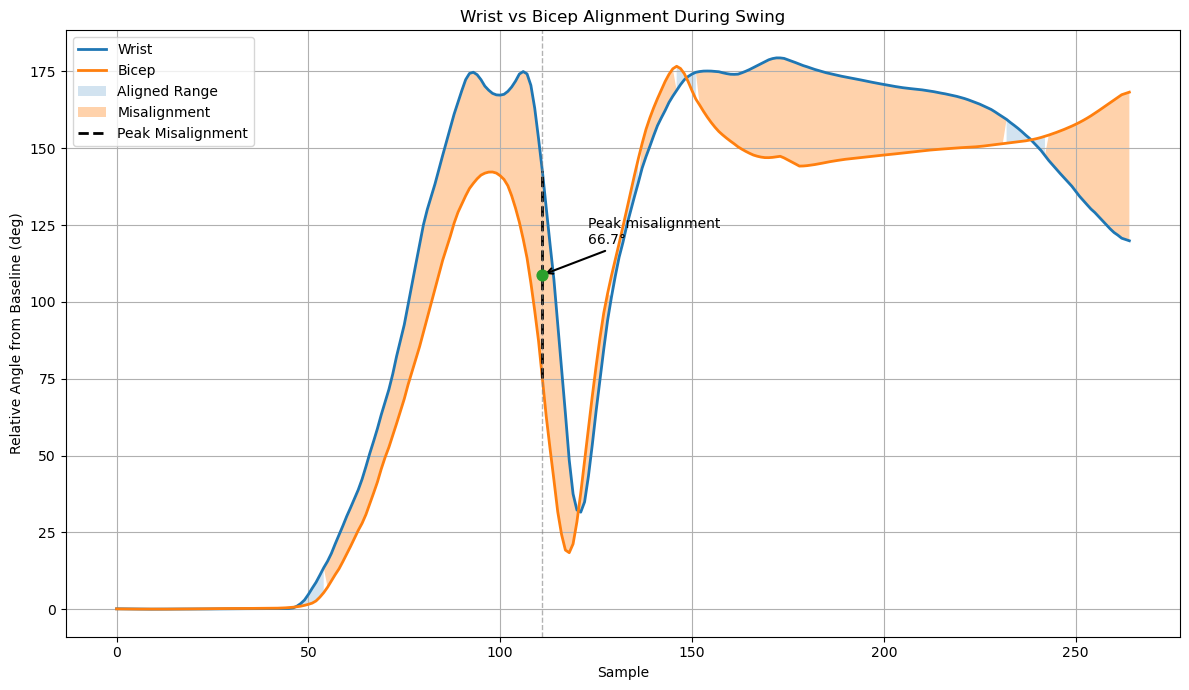

In [7]:
# =========================================================
# 12. MISALIGNMENT METRICS
# =========================================================
df["angle_diff"] = df["angle_w_s"] - df["angle_b_s"]
df["misalignment_deg"] = np.abs(df["angle_diff"])

# Smooth the misalignment a little so it looks cleaner
misalign_window = 5
df["misalignment_s"] = (
    df["misalignment_deg"]
    .rolling(window=misalign_window, center=True, min_periods=1)
    .mean()
)

# Threshold for "noticeable" misalignment / possible haptic trigger
misalignment_threshold = 8.0  # degrees, change if needed

# =========================================================
# 13. SINGLE POLISHED GRAPH
# =========================================================
plt.figure(figsize=(12, 7))

# Main motion lines
plt.plot(
    df["sample"],
    df["angle_w_s"],
    label="Wrist",
    linewidth=2
)

plt.plot(
    df["sample"],
    df["angle_b_s"],
    label="Bicep",
    linewidth=2
)

# Green shading where alignment is good
plt.fill_between(
    df["sample"],
    df["angle_w_s"],
    df["angle_b_s"],
    where=(df["misalignment_s"] <= misalignment_threshold),
    interpolate=True,
    alpha=0.20,
    label="Aligned Range"
)

# Orange/red shading where misalignment is larger
plt.fill_between(
    df["sample"],
    df["angle_w_s"],
    df["angle_b_s"],
    where=(df["misalignment_s"] > misalignment_threshold),
    interpolate=True,
    alpha=0.35,
    label="Misalignment"
)

# =========================================================
# 14. PEAK MISALIGNMENT MARKER
# =========================================================
peak_idx = df["misalignment_s"].idxmax()
peak_sample = df.loc[peak_idx, "sample"]
peak_wrist = df.loc[peak_idx, "angle_w_s"]
peak_bicep = df.loc[peak_idx, "angle_b_s"]
peak_value = df.loc[peak_idx, "misalignment_s"]

mid_y = 0.5 * (peak_wrist + peak_bicep)

# Dot at midpoint of peak deviation
plt.scatter(
    [peak_sample],
    [mid_y],
    s=60,
    zorder=5
)

# Vertical line spanning the actual deviation
plt.vlines(
    x=peak_sample,
    ymin=min(peak_wrist, peak_bicep),
    ymax=max(peak_wrist, peak_bicep),
    colors="black",
    linestyles="dashed",
    linewidth=2,
    label="Peak Misalignment"
)

# Optional full-height reference line
plt.axvline(
    x=peak_sample,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

# Annotation
plt.annotate(
    f"Peak misalignment\n{peak_value:.1f}°",
    xy=(peak_sample, mid_y),
    xytext=(peak_sample + 12, mid_y + 10),
    arrowprops=dict(arrowstyle="->", lw=1.5),
    fontsize=10
)

# =========================================================
# 15. FORMATTING
# =========================================================
plt.xlabel("Sample")
plt.ylabel("Relative Angle from Baseline (deg)")
plt.title("Wrist vs Bicep Alignment During Swing")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()